# Block 1 Checkpoint — Car Suspension
**Name:** Alex Bebb<br>
**Date:** September 13, 2026

## Modeling question

How does shock-absorber damping affect how quickly a car body
settles after a vertical disturbance?

I will model one corner of the car as a single mass supported by
a spring and damper. I will compare different damping strengths
and validate the simulation against an exact solution and a
time-step convergence check.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Model and assumptions

I represent the portion of the car body supported by one suspension
as a single point mass. A linear spring supports the mass, and a
damper exerts a force proportional to velocity and opposite to motion.

I assume the lower suspension attachment remains fixed after the
disturbance. I neglect wheel and tire motion, interactions with the
other corners of the car, and limits on suspension travel.

Position is measured upward from the loaded equilibrium position.
At equilibrium, the upward spring force balances gravity. Moving
the body upward by x reduces the upward spring force by kx, so the
net spring-and-gravity force relative to equilibrium is -kx.

Including damping gives

$$m\ddot{x}=-kx-b\dot{x},$$

or

$$\ddot{x}=-\frac{k}{m}x-\frac{b}{m}\dot{x}.$$

I start the body 0.05 m above equilibrium and release it from rest.
This represents a simplified initial disturbance, rather than
simulating the tire moving over a particular bump.

## Parameters and damping cases

I use an illustrative supported mass of 300 kg and spring constant
of 20,000 N/m. These values define a simplified example rather than
a model fitted to a particular vehicle.

The initial displacement is 0.05 m, and the initial velocity is zero.
The natural angular frequency and critical damping coefficient are

$$\omega_0=\sqrt{\frac{k}{m}},$$

$$b_{\mathrm{critical}}=2\sqrt{km}.$$

I compare damping ratios of 0.2, 1.0, and 2.0, representing weak,
critical, and strong damping. Each damping coefficient is calculated
from

$$b=\zeta b_{\mathrm{critical}}.$$

In [2]:
# Illustrative physical parameters
m = 300.0       # Supported body mass (kg)
k = 20000.0     # Spring constant (N/m)

# Initial disturbance relative to loaded equilibrium
x0 = 0.05       # Initial upward displacement (m)
v0 = 0.0        # Initial velocity (m/s)

# Characteristic quantities
omega0 = np.sqrt(k / m)          # Natural angular frequency (rad/s)
T0 = 2 * np.pi / omega0          # Undamped natural period (s)
b_critical = 2 * np.sqrt(k * m)  # Critical damping coefficient (kg/s)

# Damping ratios
zeta_weak = 0.2
zeta_critical = 1.0
zeta_strong = 2.0

# Corresponding damping coefficients (kg/s)
b_weak = zeta_weak * b_critical
b_strong = zeta_strong * b_critical

# Mechanical energy relative to equilibrium (J)
E0 = 0.5 * k * x0**2 + 0.5 * m * v0**2

print(f"Supported mass: {m:.1f} kg")
print(f"Spring constant: {k:.1f} N/m")
print(f"Initial displacement: {x0:.3f} m")
print(f"Natural angular frequency: {omega0:.4f} rad/s")
print(f"Undamped natural period: {T0:.4f} s")

print(f"\nWeak damping coefficient: {b_weak:.2f} kg/s")
print(f"Critical damping coefficient: {b_critical:.2f} kg/s")
print(f"Strong damping coefficient: {b_strong:.2f} kg/s")

print(f"\nInitial energy relative to equilibrium: {E0:.2f} J")

Supported mass: 300.0 kg
Spring constant: 20000.0 N/m
Initial displacement: 0.050 m
Natural angular frequency: 8.1650 rad/s
Undamped natural period: 0.7695 s

Weak damping coefficient: 979.80 kg/s
Critical damping coefficient: 4898.98 kg/s
Strong damping coefficient: 9797.96 kg/s

Initial energy relative to equilibrium: 25.00 J


## Numerical simulation

I use Euler-Cromer to calculate the motion after the initial
displacement. At each step, I calculate acceleration from the
current position and velocity:

$$a=-\frac{k}{m}x-\frac{b}{m}v.$$

I update velocity first, then use the updated velocity to calculate
the next position. The function stores time, position, velocity,
and mechanical energy relative to equilibrium:

$$E=\frac12kx^2+\frac12mv^2.$$

I use a fixed number of steps so that comparisons with smaller
time steps can cover the same time interval.

In [3]:
def simulate_suspension(b, dt=0.001, t_max=5.0):
    """Simulate the simplified suspension using Euler-Cromer.

    Parameters:
        b     : damping coefficient (kg/s)
        dt    : time step (s)
        t_max : requested duration (s)

    Uses m, k, x0, and v0 defined above.
    Returns arrays of time, position, velocity, and energy.
    """

    # Number of time steps
    n_steps = int(round(t_max / dt))

    # Initial state
    x = x0
    v = v0

    # Store the initial state
    t_history = [0.0]
    x_history = [x]
    v_history = [v]
    E_history = [0.5 * k * x**2 + 0.5 * m * v**2]

    for step in range(n_steps):
        # Acceleration from the current state
        a = -(k / m) * x - (b / m) * v

        # Euler-Cromer update
        v = v + a * dt
        x = x + v * dt

        # Time corresponding to the updated state
        t = (step + 1) * dt

        # Energy relative to loaded equilibrium
        energy = 0.5 * k * x**2 + 0.5 * m * v**2

        t_history.append(t)
        x_history.append(x)
        v_history.append(v)
        E_history.append(energy)

    return (
        np.array(t_history),
        np.array(x_history),
        np.array(v_history),
        np.array(E_history)
    )

## Running the damping comparison

I run the weakly damped, critically damped, and strongly damped
cases using identical initial conditions and numerical settings.
Only the damping coefficient changes.

Each simulation lasts 5 seconds with a time step of 0.001 seconds.
I keep the returned histories separate so I can compare their
motion and energy on the same plots.

In [4]:
# Shared numerical settings
dt_suspension = 0.001  # s
duration = 5.0        # s

# Weak damping
t_weak, x_weak, v_weak, E_weak = simulate_suspension(
    b=b_weak,
    dt=dt_suspension,
    t_max=duration
)

# Critical damping
t_critical, x_critical, v_critical, E_critical = simulate_suspension(
    b=b_critical,
    dt=dt_suspension,
    t_max=duration
)

# Strong damping
t_strong, x_strong, v_strong, E_strong = simulate_suspension(
    b=b_strong,
    dt=dt_suspension,
    t_max=duration
)

# Check the duration, storage, and shared initial energy
print(f"Final stored time: {t_weak[-1]:.3f} s")
print(f"Stored points per simulation: {len(t_weak)}")

print(f"\nWeak damping initial energy: {E_weak[0]:.2f} J")
print(f"Critical damping initial energy: {E_critical[0]:.2f} J")
print(f"Strong damping initial energy: {E_strong[0]:.2f} J")

Final stored time: 5.000 s
Stored points per simulation: 5001

Weak damping initial energy: 25.00 J
Critical damping initial energy: 25.00 J
Strong damping initial energy: 25.00 J


## Position versus time

I compare how the supported car body moves after being displaced
upward and released from rest. Position is measured from the loaded
equilibrium, so negative displacement means the body has moved
below that position.

I expect weak damping to allow repeated bouncing. Critical and
strong damping should return the body toward equilibrium without
repeated oscillations for these initial conditions.

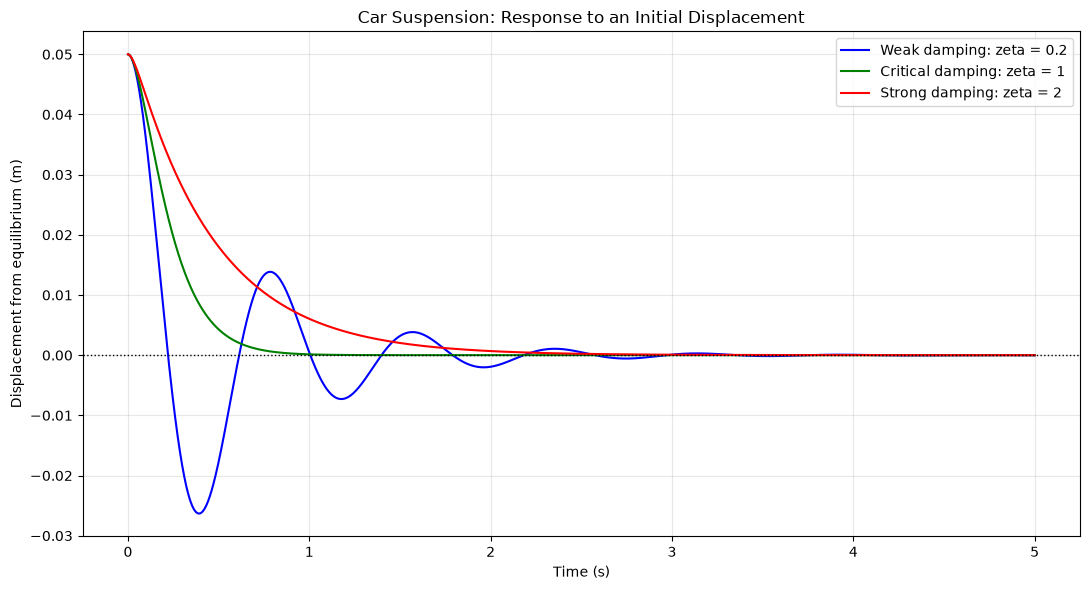

In [5]:
plt.figure(figsize=(11, 6))

plt.plot(
    t_weak, x_weak,
    color='blue',
    label='Weak damping: zeta = 0.2'
)

plt.plot(
    t_critical, x_critical,
    color='green',
    label='Critical damping: zeta = 1'
)

plt.plot(
    t_strong, x_strong,
    color='red',
    label='Strong damping: zeta = 2'
)

plt.axhline(y=0.0, color='black', linestyle=':', linewidth=1)

plt.xlabel('Time (s)')
plt.ylabel('Displacement from equilibrium (m)')
plt.title('Car Suspension: Response to an Initial Displacement')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Phase-space comparison

I plot velocity against displacement to compare the motion in
phase space. Each point pairs position and velocity at the same
stored time.

The equilibrium state is the origin, where both displacement and
velocity are zero. Weak damping should produce an inward spiral,
while critical and strong damping should approach the origin
without spiraling.

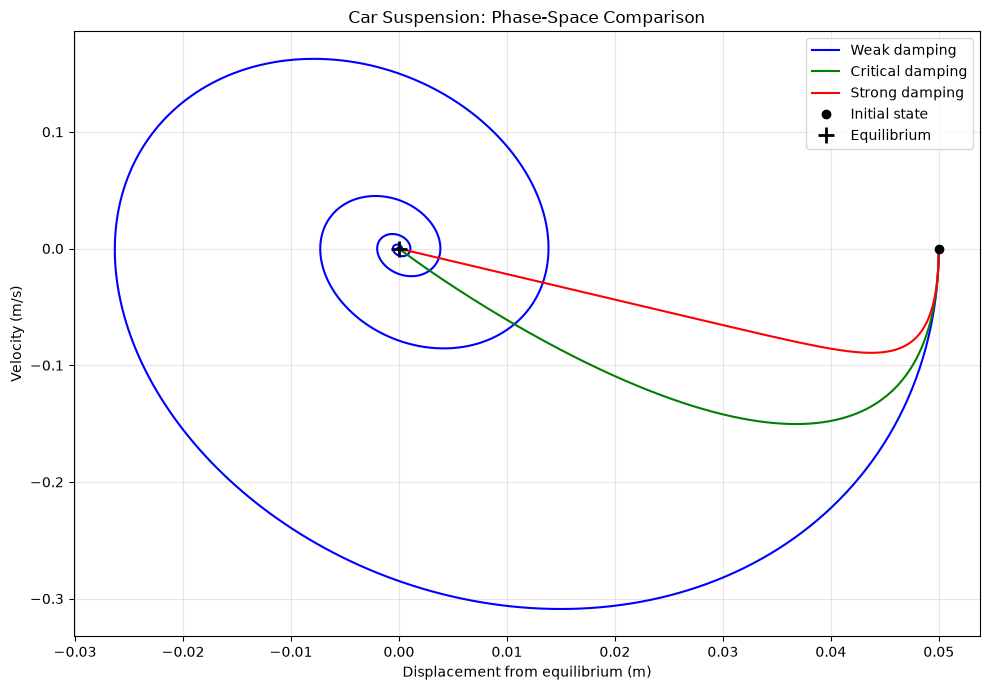

In [6]:
plt.figure(figsize=(10, 7))

plt.plot(
    x_weak, v_weak,
    color='blue',
    label='Weak damping'
)

plt.plot(
    x_critical, v_critical,
    color='green',
    label='Critical damping'
)

plt.plot(
    x_strong, v_strong,
    color='red',
    label='Strong damping'
)

plt.plot(
    x0, v0,
    marker='o',
    color='black',
    linestyle='None',
    label='Initial state'
)

plt.plot(
    0.0, 0.0,
    marker='+',
    color='black',
    linestyle='None',
    markersize=12,
    markeredgewidth=2,
    label='Equilibrium'
)

plt.xlabel('Displacement from equilibrium (m)')
plt.ylabel('Velocity (m/s)')
plt.title('Car Suspension: Phase-Space Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Mechanical energy versus time

I plot the mechanical energy relative to loaded equilibrium:

$$E=\frac12kx^2+\frac12mv^2.$$

All three cases begin with 25 J. The physical energy-loss rate is

$$\frac{dE}{dt}=-bv^2,$$

so damping removes mechanical energy whenever the body is moving.
The energy curves help interpret the motion, but they do not by
themselves establish numerical accuracy. I will also compare with
an exact solution and perform a time-step convergence check.

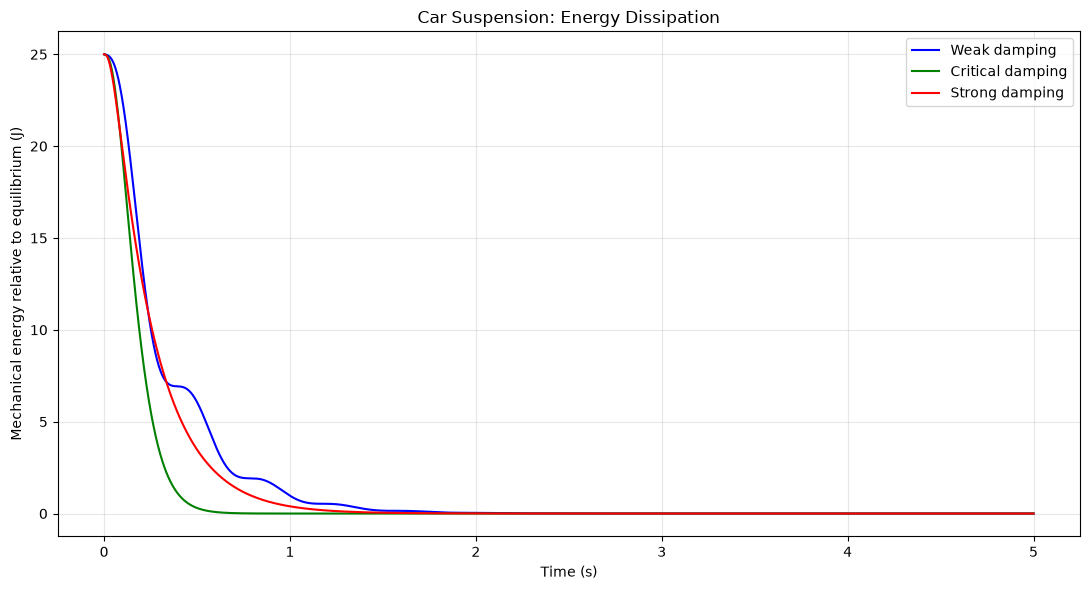

In [7]:
plt.figure(figsize=(11, 6))

plt.plot(
    t_weak, E_weak,
    color='blue',
    label='Weak damping'
)

plt.plot(
    t_critical, E_critical,
    color='green',
    label='Critical damping'
)

plt.plot(
    t_strong, E_strong,
    color='red',
    label='Strong damping'
)

plt.xlabel('Time (s)')
plt.ylabel('Mechanical energy relative to equilibrium (J)')
plt.title('Car Suspension: Energy Dissipation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Validation 1 — Comparison with an exact solution

For critical damping, the exact displacement has the form

$$x(t)=(C_1+C_2t)e^{-\omega_0t}.$$

Applying x(0) = x0 gives C1 = x0. Applying v(0) = 0 gives
C2 = omega0*x0, so

$$x_{\mathrm{exact}}(t)=x_0(1+\omega_0t)e^{-\omega_0t}.$$

I compare the numerical critically damped trajectory with this
solution at the same stored times. I also calculate the maximum
absolute position error over the simulation, expressed in meters
and as a percentage of the initial displacement.

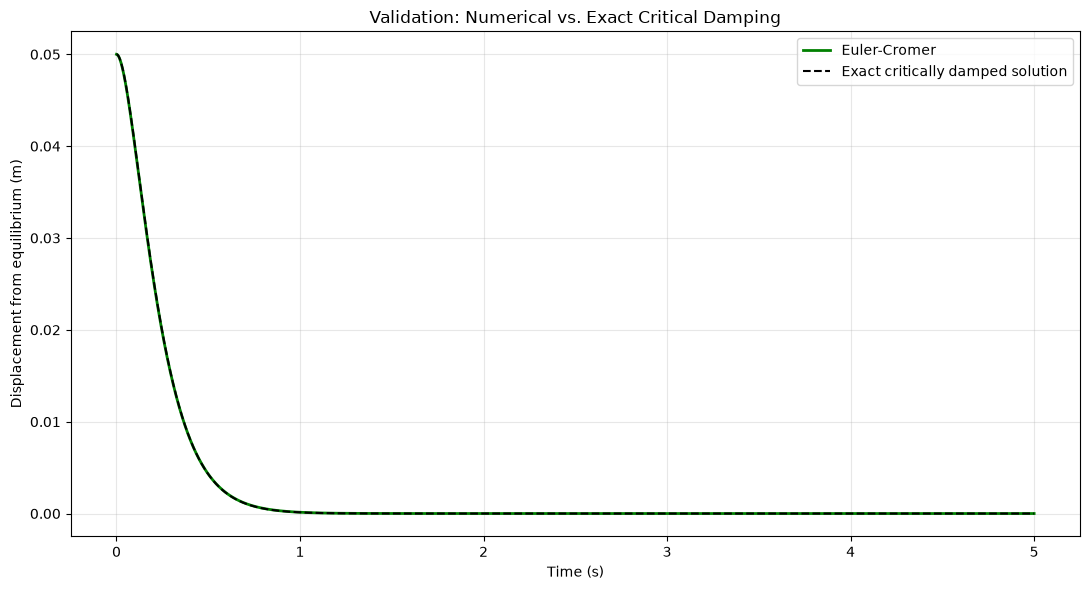

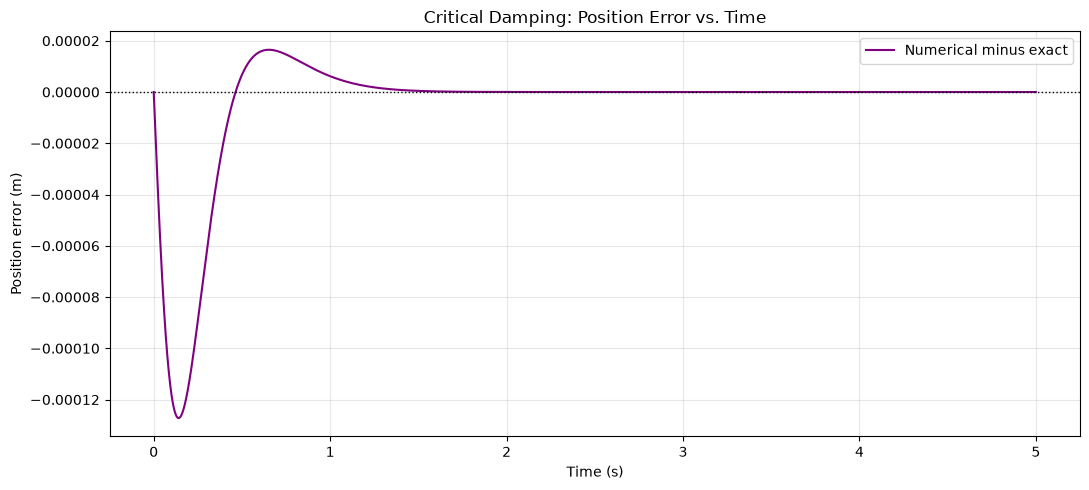

Time step: 0.001000 s
Maximum absolute position error: 0.00012721 m
Maximum error as a percentage of initial displacement: 0.254425%


In [8]:
def exact_critical_position(t):
    """Exact critically damped displacement for release from rest."""
    return x0 * (1 + omega0 * t) * np.exp(-omega0 * t)


# Evaluate the exact solution at the numerical times
x_critical_exact = exact_critical_position(t_critical)

# Signed position error and its maximum magnitude
critical_error = x_critical - x_critical_exact
max_critical_error = np.max(np.abs(critical_error))

# Normalize by the initial displacement
critical_error_percent = (
    max_critical_error / abs(x0)
) * 100

# Compare the trajectories
plt.figure(figsize=(11, 6))

plt.plot(
    t_critical, x_critical,
    color='green',
    label='Euler-Cromer',
    linewidth=2
)

plt.plot(
    t_critical, x_critical_exact,
    color='black',
    linestyle='--',
    label='Exact critically damped solution',
    linewidth=1.5
)

plt.xlabel('Time (s)')
plt.ylabel('Displacement from equilibrium (m)')
plt.title('Validation: Numerical vs. Exact Critical Damping')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot the error separately to make small differences visible
plt.figure(figsize=(11, 5))

plt.plot(
    t_critical, critical_error,
    color='purple',
    label='Numerical minus exact'
)

plt.axhline(y=0.0, color='black', linestyle=':', linewidth=1)

plt.xlabel('Time (s)')
plt.ylabel('Position error (m)')
plt.title('Critical Damping: Position Error vs. Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Time step: {dt_suspension:.6f} s")
print(f"Maximum absolute position error: {max_critical_error:.8f} m")
print(
    f"Maximum error as a percentage of initial displacement: "
    f"{critical_error_percent:.6f}%"
)

## Validation 2 — Time-step convergence

I repeat the critically damped simulation with progressively smaller
time steps, keeping the physical parameters and simulation duration
fixed.

For each run, I calculate the maximum absolute position error against
the exact solution at that run's stored times. I then plot error
against time step on logarithmic axes and estimate the slope.

If the simulation converges with first-order accuracy, halving the
time step should approximately halve the error, giving a log-log
slope close to 1.

  Time step (s)    Max error (m)   Error / |x0| (%)
       0.004000       0.00051097           1.021933
       0.002000       0.00025477           0.509538
       0.001000       0.00012721           0.254425
       0.000500       0.00006356           0.127126
       0.000250       0.00003177           0.063542

Estimated convergence order: 1.0018


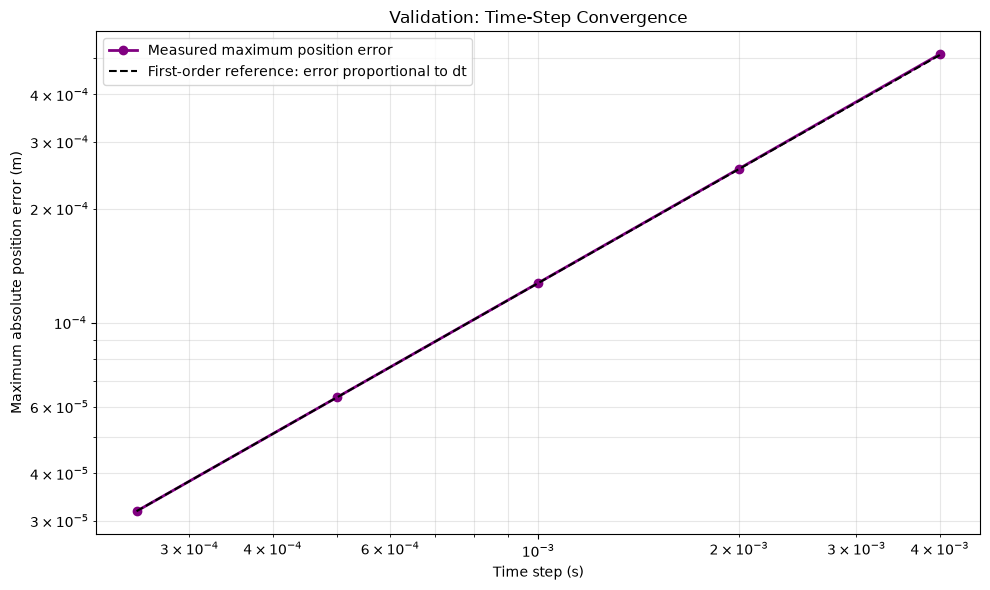

In [9]:
# Time steps to compare (s), each half the previous one
dt_values = np.array([0.004, 0.002, 0.001, 0.0005, 0.00025])

max_position_errors = []

for dt_value in dt_values:
    # Run the same physical system with this time step
    t_test, x_test, v_test, E_test = simulate_suspension(
        b=b_critical,
        dt=dt_value,
        t_max=duration
    )

    # Exact position at this run's stored times
    x_exact_test = exact_critical_position(t_test)

    # Maximum absolute position error over the run
    maximum_error = np.max(np.abs(x_test - x_exact_test))
    max_position_errors.append(maximum_error)

max_position_errors = np.array(max_position_errors)

# Print errors in meters and relative to initial displacement
print(
    f"{'Time step (s)':>15} "
    f"{'Max error (m)':>16} "
    f"{'Error / |x0| (%)':>18}"
)

for i in range(len(dt_values)):
    error_percent = max_position_errors[i] / abs(x0) * 100

    print(
        f"{dt_values[i]:15.6f} "
        f"{max_position_errors[i]:16.8f} "
        f"{error_percent:18.6f}"
    )

# Normalize by reference units before taking logarithms
dt_reference = 1.0      # s
error_reference = 1.0   # m

log_dt = np.log(dt_values / dt_reference)
log_error = np.log(max_position_errors / error_reference)

# Fit a straight line to the logarithmic data
fit = np.polyfit(log_dt, log_error, 1)
convergence_order = fit[0]

print(f"\nEstimated convergence order: {convergence_order:.4f}")

# First-order reference line, anchored at the finest-step result
first_order_reference = (
    max_position_errors[-1] * dt_values / dt_values[-1]
)

plt.figure(figsize=(10, 6))

plt.loglog(
    dt_values, max_position_errors,
    color='purple',
    marker='o',
    label='Measured maximum position error',
    linewidth=2
)

plt.loglog(
    dt_values, first_order_reference,
    color='black',
    linestyle='--',
    label='First-order reference: error proportional to dt'
)

plt.xlabel('Time step (s)')
plt.ylabel('Maximum absolute position error (m)')
plt.title('Validation: Time-Step Convergence')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Comparing settling times

I define settling time as the first stored time after which the
displacement stays within 2% of the initial displacement for the
remainder of the simulation.

With an initial displacement of 0.05 m, this tolerance is

$$0.02(0.05\ \mathrm{m})=0.001\ \mathrm{m}.$$

I check for the last time the displacement is outside this band,
rather than its first entry into the band. An oscillating system
can pass through the band and then leave it again.

This measures position settling within the recorded 5-second
interval. It does not require velocity to be exactly zero.

In [10]:
def measure_settling_time(t, x, tolerance):
    """Find when displacement stays within the tolerance band.

    Returns None if the final stored position is still outside.
    The result applies to the recorded simulation interval.
    """

    # Find all indices where displacement exceeds the tolerance
    outside_indices = np.where(np.abs(x) > tolerance)[0]

    # The entire recorded trajectory is already inside the band
    if len(outside_indices) == 0:
        return t[0]

    last_outside = outside_indices[-1]

    # No subsequent in-band point exists in this simulation
    if last_outside == len(x) - 1:
        return None

    # First stored time after the final out-of-band point
    return t[last_outside + 1]


# Position tolerance: 2% of the initial displacement
settling_tolerance = 0.02 * abs(x0)

# Measure settling time for each damping case
settling_weak = measure_settling_time(
    t_weak, x_weak, settling_tolerance
)

settling_critical = measure_settling_time(
    t_critical, x_critical, settling_tolerance
)

settling_strong = measure_settling_time(
    t_strong, x_strong, settling_tolerance
)

print(f"Position tolerance: +/- {settling_tolerance:.4f} m")

# Report the results, including cases that have not settled
settling_results = [
    ('Weak damping', settling_weak),
    ('Critical damping', settling_critical),
    ('Strong damping', settling_strong)
]

for label, settling_time in settling_results:
    if settling_time is None:
        print(f"{label}: not settled by the end of the simulation")
    else:
        print(f"{label}: settling time = {settling_time:.3f} s")

Position tolerance: +/- 0.0010 m
Weak damping: settling time = 2.398 s
Critical damping: settling time = 0.717 s
Strong damping: settling time = 1.824 s


## Results and interpretation

I modeled one corner of a car’s suspension as a 300 kg point mass supported by a linear spring and damper. The spring constant was 20,000 N/m, and the mass started 0.05 m above its loaded equilibrium position, released from rest. This represents a simplified disturbance after a bump rather than modeling the tire moving over a particular road surface. I neglected wheel motion, interactions between the car’s corners, and suspension travel limits.

Measuring displacement from loaded equilibrium accounts for the balance between gravity and the initial spring force. The resulting equation of motion is \(m\ddot{x}=-kx-b\dot{x}\), which I solved using Euler-Cromer.

Weak damping produced repeated bouncing and an inward spiral in phase space. Critical and strong damping approached equilibrium without repeated oscillations. Using a position tolerance of ±0.001 m, the measured settling times were 2.398 s for weak damping, 0.717 s for critical damping, and 1.824 s for strong damping. Critical damping settled fastest among these three cases. Increasing damping beyond the critical value slowed the return, showing that a stronger damper does not necessarily produce faster settling.

I validated the critically damped simulation against its exact solution. At a time step of 0.001 s, the maximum position error was approximately 0.00012721 m, or 0.254425% of the initial displacement. A separate time-step study showed that halving the step approximately halved the error, with a convergence slope of 1.0018.

Together, the plots and validation results support the simulation’s behavior within this simplified model. The settling times describe position remaining within the tolerance for the rest of the recorded five-second interval, rather than the body becoming completely motionless.
